Step 1:
  栄養素系列（例：過去3食分） ─▶ 時系列モデル（LSTM, Transformerなど）
                              └─▶ 次の栄養素ベクトル（数値）

Step 2:
  予測された栄養素ベクトル ─▶ 分類モデル
                             └─▶ 次の食品名を予測


In [401]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [402]:
!pip install pandas pyarrow japanize_matplotlib numpy scikit-learn kagglehub matplotlib seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


https://www.kaggle.com/datasets/utsavdey1410/food-nutrition-dataset

In [403]:
!pip freeze > requirements.txt

In [404]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [405]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utsavdey1410/food-nutrition-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\bi23014\.cache\kagglehub\datasets\utsavdey1410\food-nutrition-dataset\versions\1


In [406]:
import pandas as pd
import os
import glob

path = "C:/Users/bi23014/.cache/kagglehub/datasets/utsavdey1410/food-nutrition-dataset/versions/1/FINAL FOOD DATASET"
all_files = glob.glob(os.path.join(path, "*.csv"))

df_list = []

for filename in all_files:
     df_u = pd.read_csv(filename)
     df_list.append(df_u)

merged_df = pd.concat(df_list, ignore_index=True)    
merged_df.to_csv("./u_nutrition.csv", index=False)  # ファイル名を必要に応じて変更してください

https://www.kaggle.com/datasets/adilshamim8/daily-food-and-nutrition-dataset

In [407]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adilshamim8/daily-food-and-nutrition-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\bi23014\.cache\kagglehub\datasets\adilshamim8\daily-food-and-nutrition-dataset\versions\1


In [408]:
path = "C:/Users/bi23014/.cache/kagglehub/datasets/adilshamim8/daily-food-and-nutrition-dataset/versions/1/daily_food_nutrition_dataset.csv"

df_ad = pd.read_csv(path)
   
df_ad.to_csv("./ad_nutrition.csv", index=False)  # ファイル名を必要に応じて変更してください

https://www.kaggle.com/datasets/niharika41298/nutrition-details-for-most-common-foods

In [409]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("niharika41298/nutrition-details-for-most-common-foods")

In [410]:
path = "C:/Users/bi23014/.cache/kagglehub/datasets/niharika41298/nutrition-details-for-most-common-foods/versions/1/nutrients_csvfile.csv"

df_ni = pd.read_csv(path)

df_ni.to_csv("./ni_nutrition.csv", index=False)  # ファイル名を必要に応じて変更してください

In [436]:
path = "db_nutrition.csv"

df = pd.read_csv(path)

#前処理

In [437]:
df = df.fillna(0)

In [440]:
df = df.rename(columns={
    'Unnamed: 0': '食品群',
    'Unnamed: 1': '食品番号',
    'Unnamed: 2': '索引番号',
    '単位': "食品名",
    '%': "廃棄率(%)",
    'kJ': "エネルギー(kJ)",
    'kcal': "エネルギー(kcal)",
    '(…………… g ………………)': "水分(g)",
    'Unnamed: 8': 'アミノ酸組成によるたんぱく質(g)',
    'Unnamed: 9': 'たんぱく質(g)',
    'Unnamed: 10': '脂肪酸のトリアシルグリセロール当量(g)',
    'mg': 'コレステロール(mg)',
    '(……………………………… g ……………………………)': '脂質(g)',
    'Unnamed: 13': '利用可能炭水化物(単糖当量)(g)',
    'Unnamed: 14': 'Name1',
    'Unnamed: 15': '利用可能炭水化物(質量計)(g)',
    'Unnamed: 16': '差引き法による利用可能炭水化物(g)',
    'Unnamed: 17': 'Name2',
    'Unnamed: 18': '食物繊維総量(g)',
    'Unnamed: 19': '糖アルコール(g)',
    'Unnamed: 20': '炭水化物(g)',
    'Unnamed: 21': '有機酸(g)',
    'Unnamed: 22': '灰分(g)',
    '(…………………………… mg ……………………………)': 'ナトリウム(mg)',
    'Unnamed: 24': 'カリウム(mg)',
    'Unnamed: 25': 'カルシウム(mg)',
    'Unnamed: 26': 'マグネシウム(mg)',
    'Unnamed: 27': 'リン(mg)',
    'Unnamed: 28': '鉄(mg)',
    'Unnamed: 29': '亜鉛(mg)',
    'Unnamed: 30': '銅(mg)',
    'Unnamed: 31': 'マンガン(mg)',
    'Unnamed: 32': 'Name3',
    '(…………………………………… μg………………………………………)': 'ヨウ素(μg)',
    'Unnamed: 34': 'セレン(μg)',
    'Unnamed: 35': 'クロム(μg)',
    'Unnamed: 36': 'モリブデン(μg)',
    'Unnamed: 37': 'レチノール(μg)',
    'Unnamed: 38': 'a-カロテン(μg)',
    'Unnamed: 39': 'β-カロテン(μg)',
    'Unnamed: 40': 'β-クリプトキサンチン(μg)',
    'Unnamed: 41': 'β-カロテン当量(μg)',
    'Unnamed: 42': 'レチノール活性当量(μg)',
    'Unnamed: 43': 'ビタミンD(μg)',
    '(………… mg …………)': 'a-トコフェロール(mg)', 
    'Unnamed: 45': 'β-トコフェロール(mg)',
    'Unnamed: 46': 'γ-トコフェロール(mg)',
    'Unnamed: 47': 'σ-トコフェロール(mg)',
    'μg': 'ビタミンK(μg)',
    '(…………… mg ……………)': 'ビタミンB1(mg)',
    'Unnamed: 50': 'ビタミンB2(mg)',
    'Unnamed: 51': 'ナイアシン(mg)',
    'Unnamed: 52': 'ナイアシン当量(mg)',
    'Unnamed: 53': 'ビタミンB6(mg)',
    '(…… μg……)': 'ビタミンB12(μg)',
    'Unnamed: 55': '葉酸(μg)',
    'mg.1': 'バントテン酸(mg)',
    'μg.1': 'ビオチン(μg)',
    'mg.2': 'ビタミンC(mg)',
    '(……g……)': 'アルコール(g)',
    'Unnamed: 60': '食塩相当量(g)',
    'Unnamed: 61': 'Name4',
    'Unnamed: 62': 'Name5',
    'Unnamed: 63': 'Name6',
    'Unnamed: 64': 'Name7'
})

In [441]:
# 一行目（インデックス0）の削除
df = df.drop(index=0).reset_index(drop=True)

In [442]:
#Name削除
df = df.drop(columns=[col for col in df.columns if 'Name' in col])

In [443]:
# データフレーム内の全てのセルの値で () と - を 置換
df = df.applymap(lambda x: x.replace('(', '').replace(')', '').replace('-', '0').replace('Tr', '0') if isinstance(x, str) else x)

C:\Users\bi23014\AppData\Local\Temp\ipykernel_42200\920767670.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.replace('(', '').replace(')', '').replace('-', '0').replace('Tr', '0') if isinstance(x, str) else x)


In [444]:
# 空白文字（スペースやタブなど）を含むセルの空白文字を削除
import re

df = df.applymap(lambda x: re.sub(r'\s+', '', x) if isinstance(x, str) else x)

C:\Users\bi23014\AppData\Local\Temp\ipykernel_42200\1478160415.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: re.sub(r'\s+', '', x) if isinstance(x, str) else x)


In [445]:
df["食塩相当量(g)"].head(10)

0      0
1      0
2      0
3      0
4      0
5      0
6      0
7      0
8    2.8
9    0.2
Name: 食塩相当量(g), dtype: object

In [446]:
# すべての列（食品名以外）をfloat型に変換（object型のみ対象）
for col in df.columns:
    if col != '食品名':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 変換後の型を確認
print(df.dtypes)

食品群                     float64
食品番号                    float64
索引番号                      int64
食品名                      object
廃棄率(%)                    int64
エネルギー(kJ)                 int64
エネルギー(kcal)               int64
水分(g)                   float64
アミノ酸組成によるたんぱく質(g)       float64
たんぱく質(g)                float64
脂肪酸のトリアシルグリセロール当量(g)    float64
コレステロール(mg)               int64
脂質(g)                   float64
利用可能炭水化物(単糖当量)(g)       float64
利用可能炭水化物(質量計)(g)        float64
差引き法による利用可能炭水化物(g)      float64
食物繊維総量(g)               float64
糖アルコール(g)               float64
炭水化物(g)                 float64
有機酸(g)                  float64
灰分(g)                   float64
ナトリウム(mg)                 int64
カリウム(mg)                  int64
カルシウム(mg)                 int64
マグネシウム(mg)                int64
リン(mg)                    int64
鉄(mg)                   float64
亜鉛(mg)                  float64
銅(mg)                   float64
マンガン(mg)                float64
ヨウ素(μg)                 float64
セレン(μg) 

In [447]:
df.to_csv("new_nutrition_db.csv", index=False)

#相関分析

ad

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_1 = df_ad.drop(columns=['Food_Item','Category','Meal_Type','Date','User_ID'])
# 相関行列を計算
correlation_matrix = df_1.corr()
print(correlation_matrix)

# ヒートマップで可視化
plt.figure(figsize=(12, 10))  # 図のサイズを指定
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

db

                           食品群      食品番号      索引番号    廃棄率(%)  エネルギー(kJ)  \
食品群                   1.000000  0.999676  0.105419 -0.063710   0.128231   
食品番号                  0.999676  1.000000  0.110197 -0.060132   0.123468   
索引番号                  0.105419  0.110197  1.000000  0.016388   0.015928   
廃棄率(%)               -0.063710 -0.060132  0.016388  1.000000  -0.207787   
エネルギー(kJ)             0.128231  0.123468  0.015928 -0.207787   1.000000   
エネルギー(kcal)           0.130640  0.125903  0.016828 -0.206557   0.999831   
水分(g)                -0.059369 -0.053596 -0.005265  0.231944  -0.866771   
アミノ酸組成によるたんぱく質(g)     0.070726  0.075182  0.022365  0.034932   0.244819   
たんぱく質(g)              0.090659  0.095851  0.047308  0.042728   0.244337   
脂肪酸のトリアシルグリセロール当量(g)  0.195763  0.193544  0.028274 -0.108797   0.782077   
コレステロール(mg)           0.172369  0.176462  0.018381  0.027810   0.133161   
脂質(g)                 0.199105  0.197038  0.039730 -0.109806   0.792620   
利用可能炭水化物(単糖当量)(g)    -0.1

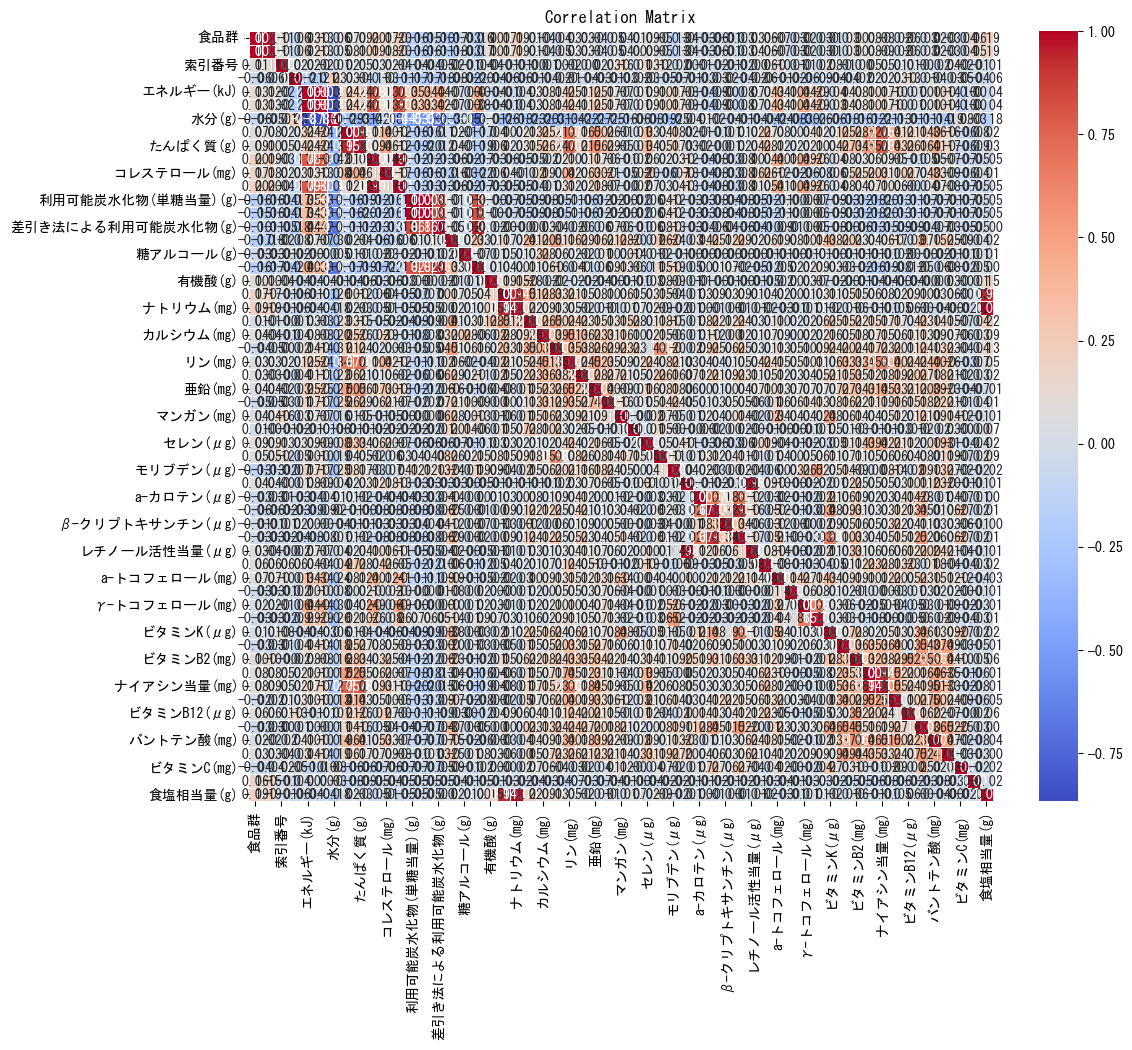

In [448]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 日本語フォントを明示的に指定
# Windowsの場合の例（MS Gothic）
plt.rcParams['font.family'] = 'MS Gothic'

# 相関行列を計算
df_numeric = df.select_dtypes(exclude=['object'])

correlation_matrix = df_numeric.corr()
print(correlation_matrix)

# ヒートマップで可視化
plt.figure(figsize=(12, 10))  # 図のサイズを指定
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix', fontname='MS Gothic')
plt.show()

In [423]:
!pip install transformers


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [424]:
!pip freeze > requirements.txt

健康度 計算

In [425]:
#不健康ラベルに使う要素の相関分析
corr = df[["ナトリウム(mg)","脂質(g)","コレステロール(mg)"]].corr(method='pearson')
corr

,ナトリウム(mg),脂質(g),コレステロール(mg)
ナトリウム(mg),1.000000,-0.053708,0.014680
脂質(g),-0.053708,1.000000,0.167614
コレステロール(mg),0.014680,0.167614,1.000000


可食部100g当たりの食品のデータ

#一日
コレステロール750mg,
ナトリウム4.5g/1000kcal,
脂質30%/ene

#人間は一日2kgの食事をとると仮定

In [449]:
#式定義

df["コレステロール(mg)"] / 0.1 > 750 / 2000
df["ナトリウム(mg)"]*1000 / df["エネルギー(kcal)"] > 4.5 / 1000
df["脂質(g)"] / df["エネルギー(kcal)"] > 0.3

0       False
1       False
2       False
3       False
4       False
        ...  
2533    False
2534    False
2535    False
2536    False
2537    False
Length: 2538, dtype: bool

In [468]:
import pandas as pd

def add_unhealthy_label(df: pd.DataFrame) -> pd.DataFrame:
    """
    3つの基準に基づいて 'unhealthy' カラムを追加する。

    条件を1つでも満たせば 'unhealthy' = 1、それ以外は 0
    """
    # 各条件の計算
    cond1 = df["コレステロール(mg)"] / 0.1 > 750 / 2000
    cond2 = df["ナトリウム(mg)"]*1000 / df["エネルギー(kcal)"] > 4.5 / 1000
    cond3 = df["脂質(g)"] / df["エネルギー(kcal)"] > 0.3

    # Trueの合計が2つ以上なら不健康
    conditions_sum = cond1.astype(int) + cond2.astype(int) + cond3.astype(int)
    df["unhealthy"] = (conditions_sum >= 2).astype(int)
    
    return df


In [469]:
df = add_unhealthy_label(df)
print(df[["unhealthy"]].value_counts())

unhealthy
0            1441
1            1097
Name: count, dtype: int64


In [470]:
from sklearn.model_selection import train_test_split
from transformers.trainer_utils import set_seed

feature_columns = [col for col in df.columns if col not in ['食品名', '食品群', '食品番号', '索引番号', '廃棄率(%)', 'コレステロール(mg)', '食塩相当量(g)', 'ナトリウム(mg)', '脂質(g)', 'エネルギー(kcal)', 'unhealthy']]
data = df[feature_columns].values
label = df['unhealthy']


set_seed(42)

分類

In [471]:
x_train,x_val,y_train,y_val = train_test_split(data, label, test_size=0.3, random_state=42)

In [472]:
# 欠損値を0で埋める
x_train = pd.DataFrame(x_train).fillna(0).values
x_val = pd.DataFrame(x_val).fillna(0).values

In [473]:
print(y_train[0:10])
print(y_train.shape)
print(df.shape)

1990    1
1456    1
514     0
409     0
2017    1
313     0
1936    1
1017    0
2379    0
916     0
Name: unhealthy, dtype: int64
(1776,)
(2538, 59)


In [474]:
# クラス分布の確認
print(label.value_counts())
print("クラス数:", label.nunique())

unhealthy
0    1441
1    1097
Name: count, dtype: int64
クラス数: 2


In [475]:
x_train

array([[5.11e+02, 7.75e+01, 9.80e+00, ..., 2.20e+01, 0.00e+00, 0.00e+00],
       [4.24e+02, 7.60e+01, 1.75e+01, ..., 8.40e+00, 1.00e+01, 0.00e+00],
       [7.80e+01, 9.39e+01, 5.00e-01, ..., 1.00e+00, 1.80e+01, 0.00e+00],
       ...,
       [7.34e+02, 1.52e+01, 0.00e+00, ..., 0.00e+00, 0.00e+00, 0.00e+00],
       [4.12e+02, 7.56e+01, 1.95e+01, ..., 1.50e+01, 0.00e+00, 0.00e+00],
       [5.40e+01, 9.53e+01, 6.00e-01, ..., 0.00e+00, 5.00e+00, 0.00e+00]],
      shape=(1776, 48))

In [478]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_val)
accuracy = accuracy_score(y_val, y_pred)
print(f'RandomForest Accuracy:{accuracy:.3f}')

RandomForest Accuracy:0.969


In [477]:
from sklearn import svm

model = svm.SVC(kernel='rbf', random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_val)
accuracy = accuracy_score(y_val, y_pred)
print(f'SVM Accuracy:{accuracy:.3f}')

SVM Accuracy:0.623


＃混同行列

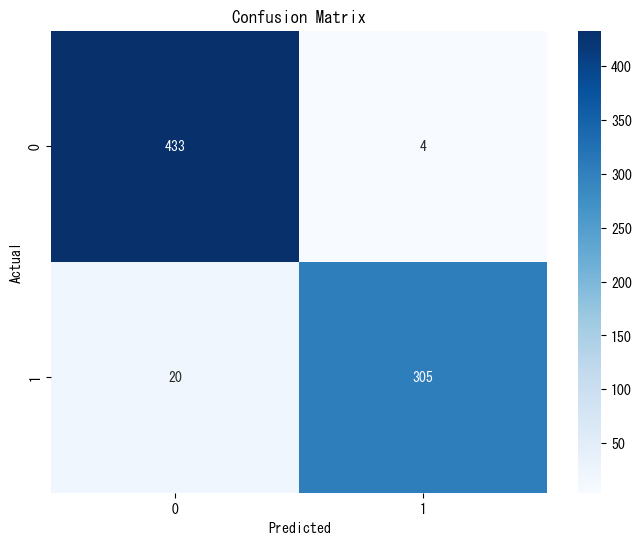

In [479]:

# 混同行列を計算して表示
cm = confusion_matrix(y_val, y_pred)
# 混同行列をヒートマップとして表示
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    annot_kws={"size": 10}
    )

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png")
plt.show()